**Dataset MPG**: Es un conjunto de datos clásico que relaciona los caballos de fuerza (horsepower) de vehículos reales de los años 70 y 80 con su rendimiento de combustible (mpg). La relación es maravillosamente no lineal.

En la librería **seaborn** para visualización, se ofrece entre otros una versión de libre acceso de este dataset, de modo que no tenemos que importarlo desde una fuente externa.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

In [2]:
# Carga del dataset MPG (miles per gallon)
df = sns.load_dataset('mpg')

# Exploración inicial
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [4]:
# Para este ejercicio, usaremos 'horsepower' (feature: variable independiente) para predecir 'mpg' (dependiente)
# Limpiamos las pocas filas que no tienen registro de caballos de potencia (missing values)
df = df.dropna(subset=['horsepower'])

X = df[['horsepower']]
y = df['mpg']

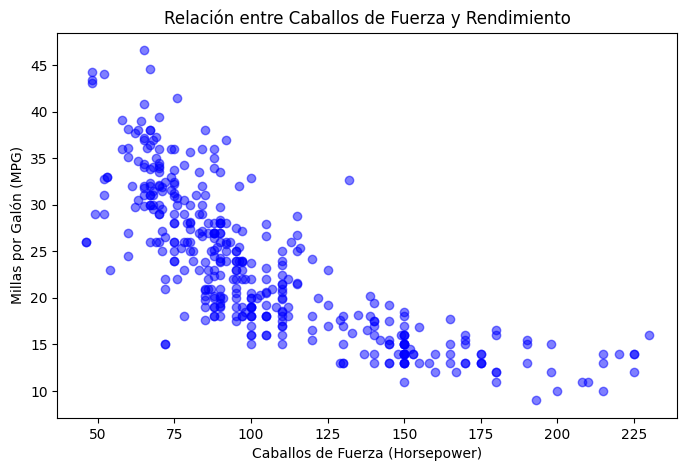

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.5)
plt.title('Relación entre Caballos de Fuerza y Rendimiento')
plt.xlabel('Caballos de Fuerza (Horsepower)')
plt.ylabel('Millas por Galón (MPG)')
plt.show()

In [6]:
# Particionado en conjuntos de entrenamiento y de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Entrenamiento y predicciones sobre datos de test, usando un modelo de regresión lineal
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)
print(f"Precisión (R2) Lineal: {r2_score(y_test, y_pred_lin):.4f}")

Precisión (R2) Lineal: 0.5660


In [8]:
# Mismo proceso, pero para un modelo de regresión polinomial de grado 2
poly_converter = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_converter.fit_transform(X_train)
X_test_poly = poly_converter.transform(X_test)

# Entrenar un nuevo modelo de regresión sobre features transformadas para comportamiento no lineal
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

y_pred_poly = poly_reg.predict(X_test_poly)
print(f"Precisión (R2) Polinomial: {r2_score(y_test, y_pred_poly):.4f}")

Precisión (R2) Polinomial: 0.6392


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


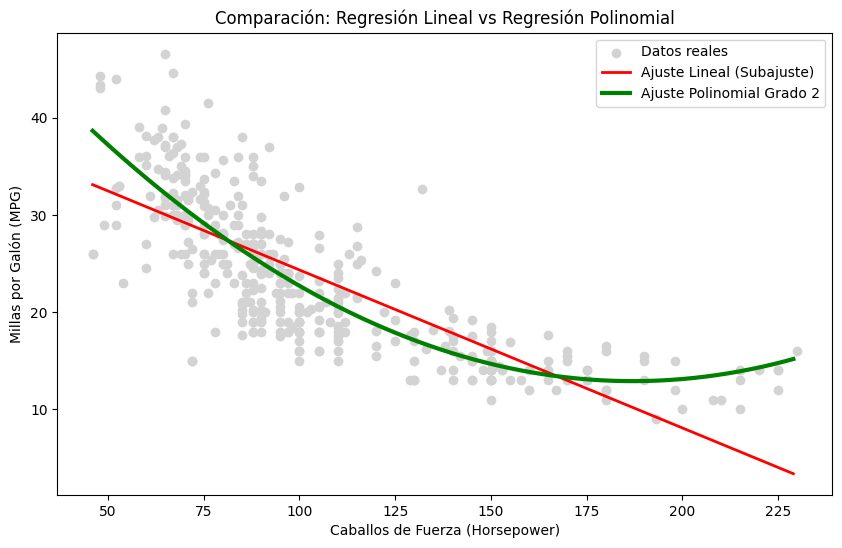

In [9]:
# Vamos a hacer una visualización comparativa entre ambos modelos
X_plot = np.arange(X['horsepower'].min(), X['horsepower'].max(), 1).reshape(-1, 1)

# Calcularemos las predicciones de un conjunto de valores x entre el mínimo y el máximo, para dibujar sendas funciones
y_plot_lin = lin_reg.predict(X_plot)
y_plot_poly = poly_reg.predict(poly_converter.transform(X_plot))

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='lightgray', label='Datos reales')
plt.plot(X_plot, y_plot_lin, color='red', linewidth=2, label='Ajuste Lineal (Subajuste)')
plt.plot(X_plot, y_plot_poly, color='green', linewidth=3, label='Ajuste Polinomial Grado 2')
plt.title('Comparación: Regresión Lineal vs Regresión Polinomial')
plt.xlabel('Caballos de Fuerza (Horsepower)')
plt.ylabel('Millas por Galón (MPG)')
plt.legend()
plt.show()

**ACTIVIDAD PROPUESTA:**
Hemos visto que la potencia (horsepower) puede predecir el consumo de forma moderadamente buena. Pero, ¿qué pasa si combinamos la potencia, el peso (weight) y el desplazamiento del motor (displacement) como predictores conjuntos del consumo?



*   Construye un modelo de Grado 2 usando estas tres variables de entrada. Compara su $R^2$ con el modelo simple que hicimos antes. ¿Mejora lo suficiente como para justificar la complejidad extra del modelo?
*   ¿Y si construimos modelos polinomiales de grados superiores a 2?



In [10]:
# ==========================================
# SOLUCIÓN
# ==========================================

# 1. Selección de múltiples variables
features = ['horsepower', 'weight', 'displacement']
X_multi = df[features]
y = df['mpg']

# 2. División de datos
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# 3. Transformación Polinomial de Grado 2 (Múltiple)
# ¡Ojo! Grado 2 con 3 variables generará términos de interacción (ej: horsepower * weight)
poly_multi = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_m = poly_multi.fit_transform(X_train_m)
X_test_poly_m = poly_multi.transform(X_test_m)

# 4. Entrenamiento
model_multi = LinearRegression()
model_multi.fit(X_train_poly_m, y_train_m)

# 5. Evaluación
y_pred_m = model_multi.predict(X_test_poly_m)
r2_multi = r2_score(y_test_m, y_pred_m)

print(f"Variables usadas: {features}")
print(f"Número de características tras transformación: {X_train_poly_m.shape[1]}")
print(f"R2 del Modelo Polinomial Múltiple: {r2_multi:.4f}")

Variables usadas: ['horsepower', 'weight', 'displacement']
Número de características tras transformación: 9
R2 del Modelo Polinomial Múltiple: 0.6787
